In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.8.0+cu126
Uninstalling torch-2.8.0+cu126:
  Successfully uninstalled torch-2.8.0+cu126
Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 829.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 145.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 111.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 114.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 136.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.

In [ ]:
import torch
torch.cuda.is_available()  # should return True if GPU is working

True

In [ ]:
pip install --upgrade transformers

In [ ]:
!pip install transformers datasets scikit-learn torch pandas

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("/content/Mental-Health-Twitter.csv")  # Your CSV path
TEXT_COL = "post_text"
LABEL_COL = "label"  # 1 = depressed, 0 = not depressed

# Basic cleaning function
import re, html
def clean_text(s):
    if pd.isna(s): return ""
    s = html.unescape(str(s))
    s = re.sub(r"http\S+", "", s)
    s = re.sub(r"@\w+", "", s)
    s = re.sub(r"#", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df[TEXT_COL].apply(clean_text)

# Split dataset
train_df, temp_df = train_test_split(df[["text_clean", LABEL_COL]], test_size=0.2, stratify=df[LABEL_COL], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df[LABEL_COL], random_state=42)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.rename(columns={"text_clean":"text", LABEL_COL:"label"}))
val_dataset = Dataset.from_pandas(val_df.rename(columns={"text_clean":"text", LABEL_COL:"label"}))
test_dataset = Dataset.from_pandas(test_df.rename(columns={"text_clean":"text", LABEL_COL:"label"}))

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments

# Tokenize datasets
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,                 # 🔥 More epochs for better performance
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,      # Effective batch = 32
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    report_to=["wandb"],                # Log directly to W&B
    fp16=True,                          # Mixed precision (if GPU available)
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,           # ✅ Use validation set here
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


## Wandb API = 17cac671cea07c4a6b25762412a99b6d14864d57

In [ ]:
import wandb
import getpass

# Securely ask for your API key
api_key = getpass.getpass("🔑 Enter your W&B API key: ")

# Log in BEFORE wandb.init()
wandb.login(key=api_key)

# Fetch user info safely (no parentheses)
api = wandb.Api()
user = api.viewer

print(f"✅ Logged in as: {user.username}")
print(f"📦 Entity: {user.entity}")

# Initialize a run/project
run = wandb.init(
    project="huggingface",
    name="RoBERTa-Depression",
    config={
        "model": "roberta-base",
        "epochs": 3,
        "batch_size": 16,
        "learning_rate": 2e-5
    }
)

print(f"🔗 Project URL: {run.url}")

🔑 Enter your W&B API key: ··········


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vishnuvainesh25 (vishnuvainesh25-karunya-institute-of-technology-and-sciences) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Logged in as: vishnuvainesh25
📦 Entity: vishnuvainesh25-karunya-institute-of-technology-and-sciences


🔗 Project URL: https://wandb.ai/vishnuvainesh25-karunya-institute-of-technology-and-sciences/huggingface/runs/qy5eyaj0


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.505600,0.408888,0.796500,0.812356,0.753636,0.881000
2,0.366000,0.366558,0.830500,0.834715,0.814462,0.856000
3,0.258500,0.407976,0.834000,0.832492,0.840122,0.825000
4,0.189500,0.403797,0.840000,0.841427,0.833988,0.849000
5,0.129800,0.572602,0.832000,0.824635,0.862445,0.790000
6,0.097100,0.648952,0.845000,0.854733,0.804233,0.912000
7,0.067500,0.911279,0.842000,0.835759,0.870130,0.804000
8,0.047900,1.057967,0.836500,0.832565,0.853095,0.813000
9,0.043900,1.053334,0.844000,0.845545,0.837255,0.854000
10,0.022100,1.086327,0.850000,0.850746,0.846535,0.855000


TrainOutput(global_step=5000, training_loss=0.17985358095169068, metrics={'train_runtime': 1668.6519, 'train_samples_per_second': 95.886, 'train_steps_per_second': 2.996, 'total_flos': 1.020880761461376e+16, 'train_loss': 0.17985358095169068, 'epoch': 10.0})

## 1. Label Distribution (Depressed vs Not Depressed)

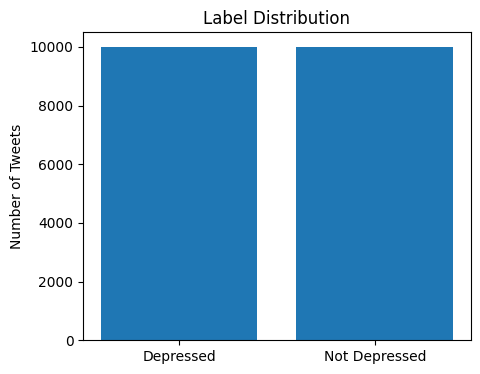

In [ ]:
import matplotlib.pyplot as plt

label_counts = df[LABEL_COL].value_counts()
plt.figure(figsize=(5,4))
plt.bar(label_counts.index.map({0:"Not Depressed", 1:"Depressed"}), label_counts.values)
plt.title("Label Distribution")
plt.ylabel("Number of Tweets")
plt.show()

# 2. Tweet Length Distribution

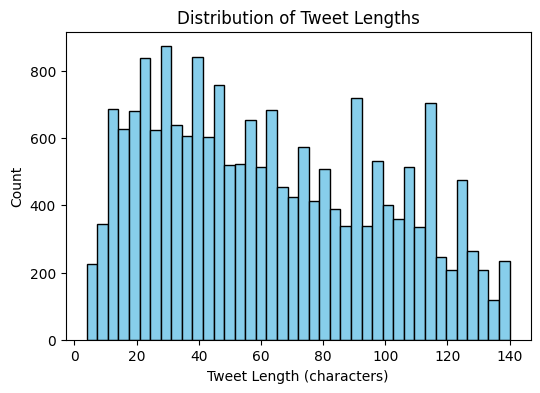

In [ ]:
df["text_length"] = df["text_clean"].apply(len)

plt.figure(figsize=(6,4))
plt.hist(df["text_length"], bins=40, color="skyblue", edgecolor="black")
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (characters)")
plt.ylabel("Count")
plt.show()

## 3. Training and Validation Accuracy/F1 (after model training)

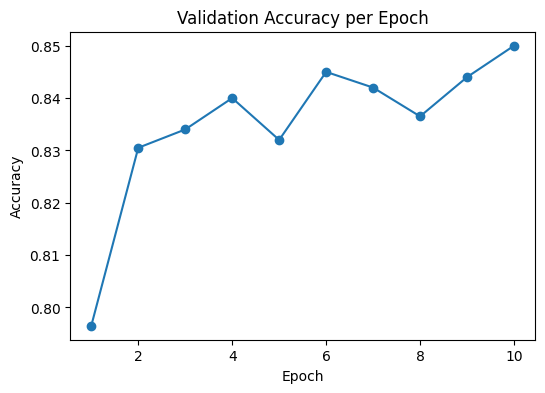

In [ ]:
import matplotlib.pyplot as plt
training_logs = trainer.state.log_history

train_acc = [x["eval_accuracy"] for x in training_logs if "eval_accuracy" in x]
epochs = range(1, len(train_acc)+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, marker='o')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## 4.Compute Metrics

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Make predictions on test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_labels = []

for batch in test_dataset:
    input_ids = batch["input_ids"].unsqueeze(0).to(device)
    attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
    label = batch["label"].item()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    pred = torch.argmax(outputs.logits, dim=1).item()

    all_preds.append(pred)
    all_labels.append(label)

# Classification report
report = classification_report(all_labels, all_preds, target_names=["Not Depressed","Depressed"])
print(report)

               precision    recall  f1-score   support

Not Depressed       0.89      0.77      0.83      1000
    Depressed       0.80      0.91      0.85      1000

     accuracy                           0.84      2000
    macro avg       0.85      0.84      0.84      2000
 weighted avg       0.85      0.84      0.84      2000



## 5.Confusion Matrix (Graphical)

✅ Total samples evaluated: 20000


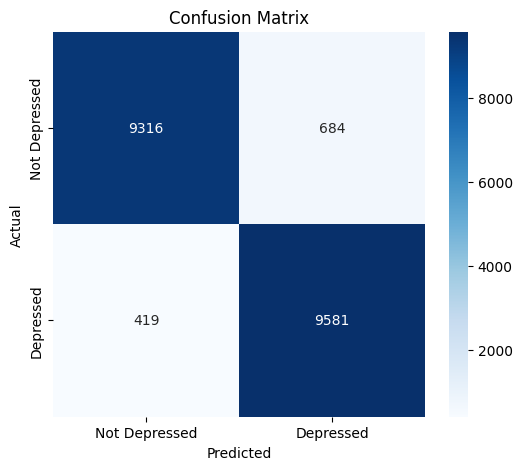

In [ ]:
# ---- Imports ----
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datasets import concatenate_datasets

# ---- Combine all splits (train + val + test) ----
# (Only if you want to evaluate the entire 20,000 samples)
full_dataset = concatenate_datasets([train_dataset, val_dataset, test_dataset])

# ---- Get predictions from your trained model ----
predictions = trainer.predict(full_dataset)

# ---- Extract predicted labels and actual labels ----
all_preds = np.argmax(predictions.predictions, axis=1)
all_labels = predictions.label_ids

print("✅ Total samples evaluated:", len(all_labels))

# ---- Compute confusion matrix ----
cm = confusion_matrix(all_labels, all_preds)

# ---- Plot confusion matrix (Counts only) ----
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Depressed", "Depressed"],
    yticklabels=["Not Depressed", "Depressed"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch

# Pick a line number safely
line_number = int(input(f"Enter the line number (0 to {len(df)-1}): "))
tweet = df.loc[line_number, TEXT_COL]
cleaned_tweet = clean_text(tweet)

# Tokenize
inputs = tokenizer(
    cleaned_tweet,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# Move inputs and model to correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_label = torch.argmax(probs, dim=-1).item()

label_map = {0: "not depressed", 1: "depressed"}

# Display results
print("\n📝 Original tweet:", tweet)
print("🧹 Cleaned tweet:", cleaned_tweet)
print(f"🔮 Predicted label: {label_map[pred_label]}")
print(f"📊 Confidence → Not Depressed: {probs[0][0]:.3f}, Depressed: {probs[0][1]:.3f}")

Enter the line number (0 to 19999): 670

📝 Original tweet: How has laziness impacted your social life? #relationships
🧹 Cleaned tweet: How has laziness impacted your social life? relationships
🔮 Predicted label: depressed
📊 Confidence → Not Depressed: 0.001, Depressed: 0.999


In [ ]:
# --- Predict depression from custom input (without modifying dataset) ---

user_input = input("Enter a text to analyze (depressed or not): ")

# Clean and tokenize
cleaned_input = clean_text(user_input)
inputs = tokenizer(cleaned_input, return_tensors="pt", truncation=True, padding=True, max_length=128)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inputs = {k: v.to(device) for k, v in inputs.items()}
model.to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
pred_label = torch.argmax(outputs.logits).item()

# Map and display
label_map = {0: "not depressed", 1: "depressed"}
print("\nOriginal text:", user_input)
print("Cleaned text:", cleaned_input)
print("Predicted label:", label_map[pred_label])

Enter a text to analyze (depressed or not): "Things will never change"

Original text: "Things will never change"
Cleaned text: "Things will never change"
Predicted label: depressed
